### Unit 1 Activity — Gestalt Principles in Data Visualization (UE24CS342AA9)

---

**2:00 PM.** You're a junior analyst at **StreamScope Analytics**. In 40 minutes you're
presenting the content-strategy dashboard to the acquisition team. Your Creative
Director, Meera, left these notes:

> *"Every one of these charts fights against how people naturally group things. Fix each
> one using the Gestalt principle it's missing — I've marked what's broken with a
> `# TODO`."*

Same dataset the team has been using: the Netflix titles catalog.

## ⏱️ Setup — run this first

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("ppt5_netflix_titles.csv")
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["year_added"] = df["date_added"].dt.year

mission_start = time.time()
print(f"Loaded {len(df):,} rows. 40 minutes on the clock. Go.")
df.head()

Loaded 8,807 rows. 40 minutes on the clock. Go.


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0


In [14]:
# Run any time to check your remaining budget
elapsed_min = (time.time() - mission_start) / 60
remaining = max(0, 40 - elapsed_min)
print(f"Elapsed: {elapsed_min:0.1f} min   |   Remaining: {remaining:0.1f} min")

Elapsed: 0.0 min   |   Remaining: 40.0 min


---
## Task 1 — Proximity

Meera's note: *"These rating bars are Movies and TV Shows all in one continuous row --
nobody can tell where one group ends and the other begins. Add a visual gap between the
two groups."*

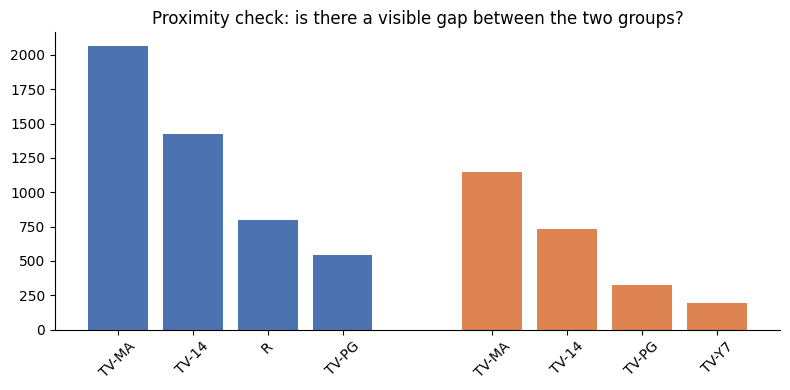

In [15]:
movie_ratings = df[df["type"] == "Movie"]["rating"].value_counts().head(4)
tv_ratings = df[df["type"] == "TV Show"]["rating"].value_counts().head(4)
all_labels = list(movie_ratings.index) + list(tv_ratings.index)
all_values = list(movie_ratings.values) + list(tv_ratings.values)

# TODO 1
positions = list(range(4)) + list(range(5, 9))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    positions,
    all_values,
    color=["#4C72B0"] * len(movie_ratings) +
          ["#DD8452"] * len(tv_ratings)
)
ax.set_xticks(positions)
ax.set_xticklabels(all_labels, rotation=45)
ax.set_title("Proximity check: is there a visible gap between the two groups?")
plt.tight_layout()
plt.show()

---
## Task 2 — Similarity

Meera's note: *"Every bar in this grouped chart is a random color right now. Movies
should be one consistent color everywhere, TV Shows another -- so the legend actually
means something."*

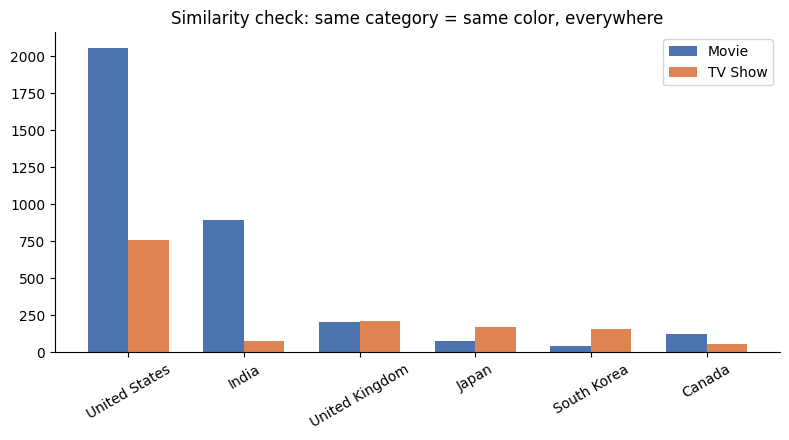

In [16]:
top_countries = df["country"].value_counts().head(6).index
sub = df[df["country"].isin(top_countries)]
grouped = sub.groupby(["country", "type"]).size().unstack(fill_value=0).loc[top_countries]

x = np.arange(len(grouped))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4.5))

# TODO 2
movie_color = "#4C72B0"
tv_color = "#DD8452"

ax.bar(x - width/2, grouped["Movie"], width, label="Movie", color=movie_color)
ax.bar(x + width/2, grouped["TV Show"], width, label="TV Show", color=tv_color)

ax.set_xticks(x)
ax.set_xticklabels(grouped.index, rotation=30)
ax.legend()
ax.set_title("Similarity check: same category = same color, everywhere")
plt.tight_layout()
plt.show()

---
## Task 3 — Connectedness

Meera's note: *"This 2019-vs-2020 comparison is just two separate bar groups -- the
year-over-year *change* is the actual story, and right now it's invisible. Connect each
country's two points with a line."*

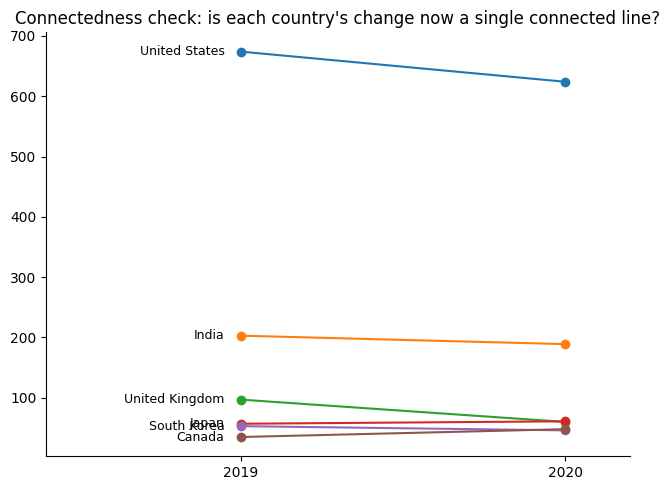

In [17]:
yearly = df[df["year_added"].isin([2019, 2020])]
counts = yearly[yearly["country"].isin(top_countries)].groupby(
    ["country", "year_added"]
).size().unstack(fill_value=0)

counts = counts.loc[top_countries]

fig, ax = plt.subplots(figsize=(6.5, 5))

for country in counts.index:
    y2019, y2020 = counts.loc[country, 2019], counts.loc[country, 2020]

    # TODO 3
    ax.plot([0, 1], [y2019, y2020], marker="o")

    ax.text(-0.05, y2019, country, ha="right", va="center", fontsize=9)

ax.set_xticks([0, 1])
ax.set_xticklabels(["2019", "2020"])
ax.set_xlim(-0.6, 1.2)
ax.set_title("Connectedness check: is each country's change now a single connected line?")
plt.tight_layout()
plt.show()

---
## Task 4 — Continuity

Meera's note: *"This line chart's x-axis is in random order -- the eye can't trace a
path through it. Sort it chronologically."*

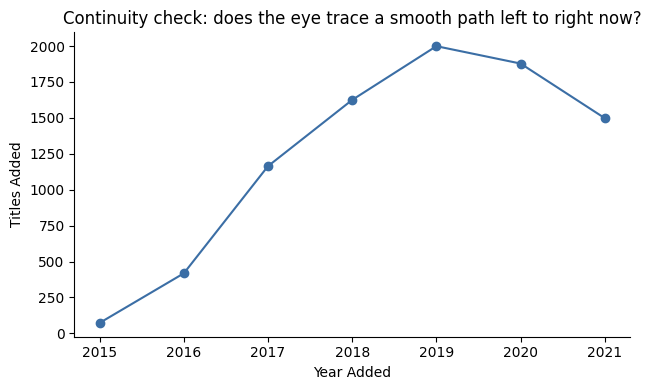

In [18]:
by_year = df["year_added"].value_counts()
by_year = by_year[by_year.index >= 2015]
shuffled = by_year.sample(frac=1, random_state=1)

# TODO 4: create 'ordered' by sorting into chronological order
ordered = shuffled.sort_index()

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(ordered.index, ordered.values, marker="o", color="#3b6ea5")
ax.set_xlabel("Year Added")
ax.set_ylabel("Titles Added")
ax.set_title("Continuity check: does the eye trace a smooth path left to right now?")
plt.tight_layout()
plt.show()

---
## Task 5 — Symmetry

Meera's note: *"Give me a back-to-back bar chart -- Movies on the left, TV Shows on the
right, mirrored around a center line -- so it's easy to compare the two distributions at
a glance."*

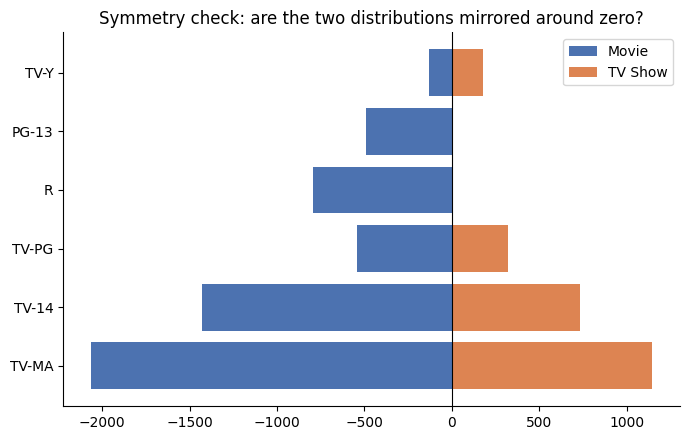

In [19]:
ratings = ["TV-MA", "TV-14", "TV-PG", "R", "PG-13", "TV-Y"]
movie_counts = df[df["type"] == "Movie"]["rating"].value_counts().reindex(ratings, fill_value=0)
tv_counts = df[df["type"] == "TV Show"]["rating"].value_counts().reindex(ratings, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4.5))
y = np.arange(len(ratings))

# TODO 5
ax.barh(y, -movie_counts.values, color="#4C72B0", label="Movie")
ax.barh(y, tv_counts.values, color="#DD8452", label="TV Show")

ax.set_yticks(y)
ax.set_yticklabels(ratings)
ax.axvline(0, color="black", lw=0.8)
ax.legend()
ax.set_title("Symmetry check: are the two distributions mirrored around zero?")
plt.tight_layout()
plt.show()

---
## Task 6 — Closure

Meera's note: *"Turn this pie chart into a donut with visible gaps between segments --
it should still read as one complete ring, not five separate pie slices."*

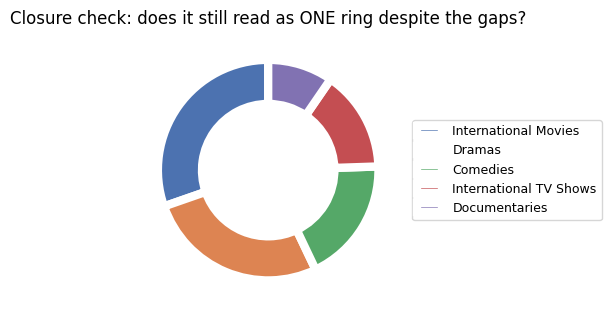

In [20]:
top_genres = df["listed_in"].str.split(", ").explode().value_counts().head(5)

fig, ax = plt.subplots(figsize=(5, 5))

# TODO 6
wedges, _ = ax.pie(
    top_genres.values,
    colors=["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"],
    startangle=90,
    wedgeprops={
        "width": 0.4,
        "edgecolor": "white",
        "linewidth": 6
    }
)

ax.legend(
    wedges,
    top_genres.index,
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=9
)

ax.set_title("Closure check: does it still read as ONE ring despite the gaps?")
plt.tight_layout()
plt.show()

---
## Task 7 — Common Region

Meera's note: *"These three summary numbers are just floating text right now -- put a
card/border around each one so they read as distinct, self-contained metrics."*

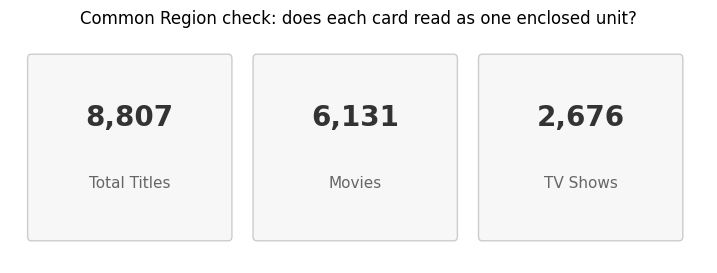

In [21]:
metrics = [
    ("Total Titles", f"{len(df):,}"),
    ("Movies", f"{(df['type']=='Movie').sum():,}"),
    ("TV Shows", f"{(df['type']=='TV Show').sum():,}"),
]

fig, ax = plt.subplots(figsize=(9, 3))
ax.axis("off")

for i, (label, value) in enumerate(metrics):
    x0 = i * 3.2

    # TODO 7
    ax.add_patch(
        patches.FancyBboxPatch(
            (x0, 0),
            2.8,
            2,
            boxstyle="round,pad=0.05",
            linewidth=1,
            edgecolor="#cccccc",
            facecolor="#f7f7f7"
        )
    )

    ax.text(
        x0 + 1.4, 1.25, value,
        ha="center",
        fontsize=20,
        fontweight="bold",
        color="#333333"
    )

    ax.text(
        x0 + 1.4, 0.55, label,
        ha="center",
        fontsize=11,
        color="#666666"
    )

ax.set_xlim(-0.3, 3 * 3.2)
ax.set_ylim(-0.3, 2.3)
ax.set_title("Common Region check: does each card read as one enclosed unit?")
plt.show()

---
## Task 8 — Figure & Ground

Meera's note: *"This chart's bars are barely darker than the background -- fix the
contrast so the bars are unmistakably the 'figure.'"*

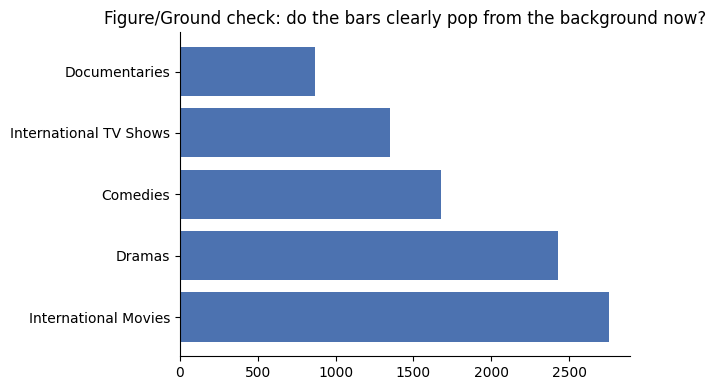

In [22]:
top5 = df["listed_in"].str.split(", ").explode().value_counts().head(5)

fig, ax = plt.subplots(figsize=(6.5, 4))

# TODO 8
ax.set_facecolor("white")
ax.barh(top5.index, top5.values, color="#4C72B0")

ax.set_title("Figure/Ground check: do the bars clearly pop from the background now?")
plt.tight_layout()
plt.show()

---
## Task 9 — Common Fate

Meera's note: *"In this small-multiples trend chart, highlight only the country whose
titles are RISING the fastest -- every other line should fade into gray so the rising
one visually 'groups' with the word 'growth.'"*

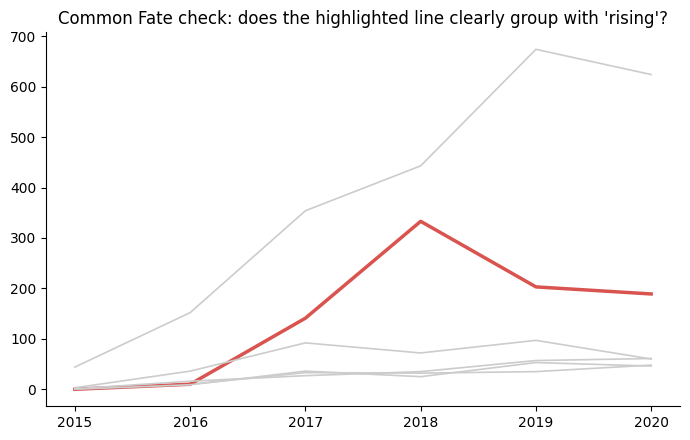

In [23]:
by_year_country = df[df["country"].isin(top_countries)].groupby(
    ["year_added", "country"]
).size().unstack(fill_value=0)

by_year_country = by_year_country.loc[
    (by_year_country.index >= 2015) &
    (by_year_country.index <= 2020)
]

# TODO 9
fastest_riser = (
    by_year_country.iloc[-1] / by_year_country.iloc[0]
).idxmax()

fig, ax = plt.subplots(figsize=(7, 4.5))

for country in by_year_country.columns:
    color = "#D9534F" if country == fastest_riser else "#cccccc"
    lw = 2.5 if country == fastest_riser else 1.2
    ax.plot(
        by_year_country.index,
        by_year_country[country],
        color=color,
        lw=lw
    )

ax.set_title("Common Fate check: does the highlighted line clearly group with 'rising'?")
plt.tight_layout()
plt.show()

---
## Reflection

Answer briefly in this markdown cell:

1. Which one of the nine Gestalt fixes above would you argue matters *most* for a
   dashboard viewed for only a few seconds, and why?
2. Pick two principles that worked together in the same chart (e.g. Task 1's proximity
   + Task 2's similarity) — how did they reinforce each other?
3. In one sentence, restate the chapter's core idea: Gestalt principles let a chart's
   *__________* do the organizing work instead of the *__________*.



**Your answers:**

1. I would argue that **Figure & Ground** matters most for a dashboard viewed for only a few seconds because strong contrast makes the important data stand out immediately and directs the viewer's attention.

2. **Proximity and Similarity** worked together in the same chart. Proximity grouped the Movie and TV Show bars into clear categories, while Similarity used consistent colors to make the categories easy to recognize.

3. Gestalt principles let a chart's **visual perception** do the organizing work instead of the **viewer**.